# Calibration & Threshold Selection

*How much can we trust the model's probabilities, and where should we draw the line to act on them?*

A model can rank customers correctly — putting likely churners above unlikely ones — while still getting the actual probabilities wrong. **Calibration** is what fixes that: a well-calibrated model's 0.7 means "about 70% of these customers actually churn," not just "these customers rank higher than the 0.3s." That distinction matters here because the threshold this notebook derives only makes sense against honest probabilities.

This notebook walks through two already-computed results: how the calibration method was chosen (Section 2), and how the calibrated probabilities were converted into a single, cost-based threshold for deciding who to contact (Section 3).

In [1]:
%matplotlib inline

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

import mlflow
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv()

from telco_churn.utils.logging import configure_logging
from telco_churn.utils.mlflow import resolve_tracking_uri
from telco_churn.utils.paths import compose_config

configure_logging()
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1. Load the calibration + threshold run from MLflow

### Connect and locate the run

Calibration and threshold derivation are both logged onto the *same* MLflow run as the `tuning_study` parent — not separate named runs — since `calibrate.py` performs the training cycle's single registration by rebinding that run's model artifact rather than creating a new one. This notebook pulls the **most recent** `tuning_study` run that has a logged `threshold.json` — the last artifact in the chain — which excludes any run where calibration or threshold derivation was interrupted partway through.

In [2]:
cfg = compose_config()

mlflow.set_tracking_uri(resolve_tracking_uri(str(cfg.mlflow.tracking_uri)))

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(cfg.mlflow.experiment_name)
if exp is None or exp.lifecycle_stage != "active":
    raise RuntimeError(
        f"No active MLflow experiment named '{cfg.mlflow.experiment_name}' found "
        f"(tracking_uri={mlflow.get_tracking_uri()}). Run the training, calibration, "
        "and threshold steps first."
    )

runs = client.search_runs(
    [exp.experiment_id],
    filter_string="attributes.run_name = 'tuning_study'",
    order_by=["start_time DESC"],
    max_results=20,
)
run_id = None
for run in runs:
    artifact_names = {a.path for a in client.list_artifacts(run.info.run_id)}
    if "threshold.json" in artifact_names:
        run_id = run.info.run_id
        break
if run_id is None:
    raise RuntimeError(
        f"No 'tuning_study' run with a logged 'threshold.json' found in experiment "
        f"'{cfg.mlflow.experiment_name}'. Run calibrate.py then threshold.py first."
    )

print(f"run_id: {run_id}")

run_id: 2f168483000e45a7b8c0a16ff68b4064


## 2. Calibration — method selection

### Sigmoid vs. isotonic, on outer-OOF development probabilities

Two calibration methods — **sigmoid** and **isotonic** — are compared against the uncalibrated baseline on identical cross-validation folds. Isotonic is disqualified first if it makes the model's customer-ranking ability (PR-AUC) meaningfully worse: a calibration method should sharpen probabilities, not damage risk-ranking. Only a method that clears that check is then judged on calibration quality — **Brier score** and **Expected Calibration Error (ECE)**, both explained below.

In [3]:
calibration_summary = mlflow.artifacts.load_dict(f"runs:/{run_id}/calibration_summary.json")

diagnostics_df = pd.DataFrame(calibration_summary["diagnostics"]).T
diagnostics_df.columns = ["per_fold_mean_ap", "pooled_brier", "ece", "bss"]
display(diagnostics_df.style.format("{:.4f}"))

print(f"\nSelected method: {calibration_summary['method']}")
switch = calibration_summary.get("switch_decision")
if switch:
    print(f"Decision rule: {switch['decision_rule']}")

,per_fold_mean_ap,pooled_brier,ece,bss
dummy_prior,0.2654,0.1949,0.0000,0.0000
uncalibrated,0.6684,0.1604,0.1402,0.1770
sigmoid,0.6684,0.1343,0.0222,0.3111
isotonic,0.6474,0.1342,0.0122,0.3117



Selected method: sigmoid
Decision rule: pinned


**Brier score** measures how close predicted probabilities are to what actually happened (lower is better). **Expected Calibration Error (ECE)** measures the average gap between predicted and observed rates across probability bins (also lower is better). Isotonic wins on both — but it degrades ranking past the pre-set threshold, so it's disqualified before its calibration scores even count. Sigmoid keeps ranking exactly intact while still recovering most of isotonic's calibration gain.

Brier score alone is hard to judge in isolation — 0.13 doesn't mean much without a reference point. **Brier Skill Score (BSS)** fixes this by comparing each method to a naive baseline that always guesses the overall churn rate (`dummy_prior`, BSS = 0 by definition). Sigmoid's BSS of 0.31 means the calibrated model captures 31% of the possible improvement over that naive guess.

### Reliability diagram — does calibration actually help?

**Short answer: yes, and by a wide margin.** The chart below plots the model's raw, uncalibrated probabilities (blue) against its calibrated ones (orange). The blue line sits below the diagonal almost everywhere, which means the raw model consistently overstated how likely customers were to churn. The orange line hugs the diagonal instead. That gap between the two lines *is* what "calibration helps" looks like on this kind of chart — the rest of this section explains how to read it and why the difference matters for decisions built on top of these probabilities.

**How to read it:** customers are grouped by predicted probability, then checked against what actually happened to them. The **top panel** plots each group's predicted churn rate (x-axis) against its actual churn rate (y-axis) — the closer a point sits to the dashed diagonal, the more trustworthy that probability is. A point *below* the diagonal means the model over-predicted risk for that group; a point *above* means it under-predicted. The **bottom panel** shows how many customers fall into each group, so a point backed by hundreds of customers can be told apart from one backed by just a handful.


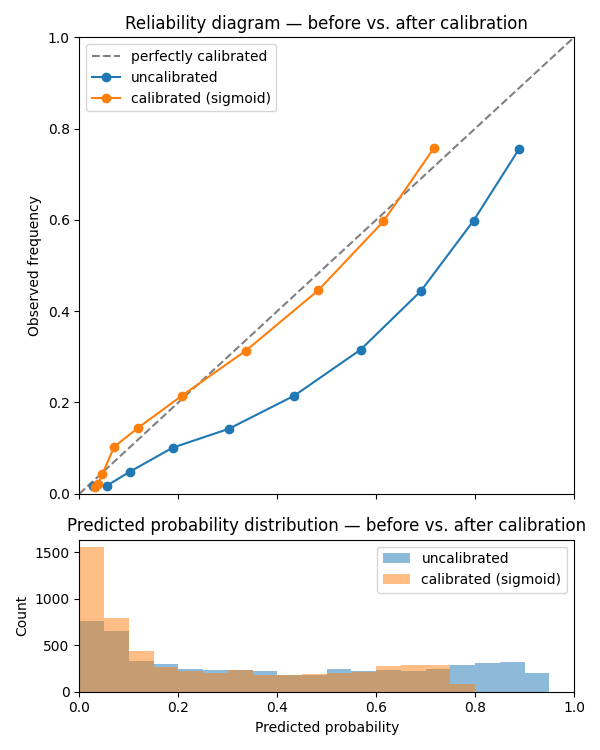

In [4]:
reliability_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/reliability_diagram.png"
)
display(Image(filename=reliability_path))

**Uncalibrated (blue): overconfident, consistently.** Its points sit below the diagonal at essentially every probability level — a one-directional gap, not scattered noise. Take the customers it scored around 87% likely to churn: only 76% of them actually did. That's not a one-off miss — the same kind of overstatement repeats all the way along the curve. In plain terms: handed these raw numbers, a business stakeholder would be told every customer is a bigger flight risk than they really are. This overconfidence is a side effect of a training technique that helps the model notice rarer churn cases — it sharpens the model's ability to *rank* customers correctly, but it inflates every probability it outputs along the way.

**Calibrated (orange): honest, on average.** After calibration, the points scatter on **both sides** of the diagonal — a little high in some bins, a little low in others — rather than leaning the same direction everywhere. That distinction (one-directional vs. bidirectional) is exactly what separates *genuine miscalibration* from *ordinary sampling noise*: each point here is an observed rate from a finite bin of customers, so some scatter around the diagonal is expected even for an honestly calibrated model. A consistent lean in one direction, the way the blue line shows, is not that — it's a signature of systematic bias, and it's the thing calibration fixed. The next section puts a number on this distinction directly, rather than leaving it to the eye.

**Why the fix matters, concretely:** the cost-based threshold `t*` derived later in this notebook only makes sense if a customer scored at 40% actually churns about 40% of the time. Before calibration, that assumption was off by a wide, predictable margin; after calibration, it holds. Skipping this step wouldn't have hurt the model's ability to *rank* customers from most to least likely to churn — that part was already fine — but it would have quietly poisoned every dollar figure built on top of the raw probabilities, since those calculations take the number at face value rather than just its rank.

The histogram below shows the same shift from a different angle — a distribution, not a curve. Only about 26.5% of customers actually churn, so most customers are genuinely low-risk; a calibrated model should predict a low probability for most of them, with a smaller stretch of higher predictions reserved for the ones who really are likely to leave. That's the shape the calibrated (orange) histogram takes: a tall cluster near 0% and a thinning tail out toward 100% — not a claim that "near 0%" numerically equals 26.5%, but that the distribution's shape is what you'd expect when only about a quarter of customers are actual churners. The uncalibrated (blue) histogram instead pushes predictions further right across the board — the same overconfidence from the diagonal above, seen here as a shifted distribution rather than a shifted line. (The next section turns this into an exact number: the calibrated model's *average* prediction lands within a point of the true 26.5% churn rate, while the uncalibrated model's average overshoots it by about 14 points — that average, not the shape, is the number that actually has to match.)


### Calibration slope — is the model honest at the extremes?

The **calibration slope** (Cox, 1958) is a standard check from clinical risk modelling: fit a regression of the true outcome against the predicted probabilities. The slope of that fit is the number that matters:

- **1.0 = perfectly calibrated.**
- **Below 1.0 = overconfident at the extremes** — predictions near 0%/100% overstate how sure the model should be.
- **Above 1.0 = underconfident at the extremes** — the model is too cautious exactly where it should be decisive.

It catches something Brier score and ECE can miss: a model can *rank* customers better while becoming *less honest* at the extremes.

**Reference band:** **[§0 Problem Framing & Cost Definition](../ANALYSIS.md#0-problem-framing--cost-definition)** defines **[0.80, 1.25]** as the binding pass range for this statistic — but only as computed on the **sealed test set**, in `evaluate.py`. The table below applies the same band to the **dev-OOF** vector this cycle's calibration-method choice actually rests on, purely as an early read: it confirms the reliability diagram's story with a number, and lets a future retrain cycle tell "still in range" from "genuinely drifting" without opening `calibration_summary.json`. Nothing here decides promotion — that number belongs to `evaluate.py` alone.

In [5]:
band_lower, band_upper = 0.80, 1.25  # §0's reference band, applied here to dev-OOF as an early read — not the binding sealed-test gate


def _band_read(slope_dict: dict) -> str:
    # Same in/out-of-range test §0 specifies for the sealed-test gate, applied
    # here to the dev-OOF vector for an early read, not a promotion decision.
    ci_lower, ci_upper = slope_dict["slope_ci_lower"], slope_dict["slope_ci_upper"]
    outside = ci_upper < band_lower or ci_lower > band_upper
    return "outside range" if outside else "within range"


rows = []
for label, key in [
    ("Calibrated (sigmoid)", "calibration_slope"),
    ("Uncalibrated", "uncalibrated_calibration_slope"),
]:
    s = calibration_summary[key]
    rows.append(
        {
            "model": label,
            "slope": s["slope"],
            "intercept": s["intercept"],
            "95% bootstrap CI": "[{:.4f}, {:.4f}]".format(
                s["slope_ci_lower"], s["slope_ci_upper"]
            ),
            "dev-OOF read [{}, {}]".format(band_lower, band_upper): _band_read(s),
        }
    )
slope_comparison_df = pd.DataFrame(rows).set_index("model")
display(slope_comparison_df)

print(
    "Mean p_hat: calibrated={:.4f}  uncalibrated={:.4f}  observed churn rate={:.4f}".format(
        calibration_summary["mean_p_hat_calibrated"],
        calibration_summary["mean_p_hat_uncalibrated"],
        calibration_summary["observed_churn_rate"],
    )
)

,slope,intercept,95% bootstrap CI,"dev-OOF read [0.8, 1.25]"
model,,,,
Calibrated (sigmoid),1.013539,0.001691,"[0.9603, 1.0707]",within range
Uncalibrated,0.981621,-0.975491,"[0.9252, 1.0425]",within range


Mean p_hat: calibrated=0.2662  uncalibrated=0.4055  observed churn rate=0.2654


**Both read within range — but "within range" doesn't mean "was fine."** The reliability diagram already showed the uncalibrated model was miscalibrated; this check just tests a narrower thing, on dev-OOF data. Two different failures can hide in a set of probabilities: a **level** problem (a bathroom scale stuck 5 lbs high for everyone, regardless of their actual weight) and a **spread** problem (a stopwatch that drifts further off the longer it runs) — and the slope only tests spread. The uncalibrated model's slope is already close to 1.0 (0.98), so its *relative* ranking of who's riskier was already reasonably honest; its actual problem is the **intercept**, shifted far from 0 and matching a mean prediction far above the true churn rate (table above) — a level problem the slope can't see.

On the reliability diagram, this is the one-directional gap: near-zero error at low predictions, widening toward the top — the signature of a roughly constant offset, not a growing one. *(Technical aside: a constant shift in log-odds space produces exactly this shape once converted back to probabilities.)* Calibration removes that offset, leaving only the ordinary sampling noise of estimating a rate from a finite group of customers. **Takeaway:** this check catches one specific failure — bad relative judgement at the extremes, not every way probabilities can be dishonest — and it's not a substitute for the reliability diagram; the mean p̂ printed above puts a number on the same level problem it misses: 26.62% calibrated vs. 26.54% observed (a near-exact match), versus 40.55% uncalibrated, about 14 points too high on average across the whole customer base.


### Bootstrap vs. analytic (Wald) CI cross-check

The table above reports a **percentile bootstrap** CI for the calibration slope — resampling rows and refitting the auxiliary regression on each draw. A percentile bootstrap has no guaranteed coverage in general (small samples or a skewed sampling distribution can make it misbehave), so `calibrate.py::calibration_slope` also reports a closed-form **analytic (Wald) CI**, derived from the asymptotic covariance of the logistic-regression MLE — no resampling involved. It is a cross-check, not a replacement: the bootstrap CI remains the one the gate reads.

The analytic standard error's own math is independently verified in `tests/unit/test_calibrate.py` against a numerical finite-difference Hessian of the same log-likelihood (no shared code path) — that check runs at CI time, not here. What this cell answers is the practical question: on *this run's* actual dev-OOF probabilities, do the two methods actually agree?


In [6]:
cal_slope = calibration_summary["calibration_slope"]

wald_df = pd.DataFrame(
    {
        "lower": [cal_slope["slope_ci_lower"], cal_slope["slope_ci_lower_analytic"]],
        "upper": [cal_slope["slope_ci_upper"], cal_slope["slope_ci_upper_analytic"]],
    },
    index=["bootstrap", "analytic (Wald)"],
)
display(wald_df)

bootstrap_width = cal_slope["slope_ci_upper"] - cal_slope["slope_ci_lower"]
analytic_width = (
    cal_slope["slope_ci_upper_analytic"] - cal_slope["slope_ci_lower_analytic"]
)
bootstrap_center = (cal_slope["slope_ci_upper"] + cal_slope["slope_ci_lower"]) / 2
analytic_center = (
    cal_slope["slope_ci_upper_analytic"] + cal_slope["slope_ci_lower_analytic"]
) / 2

print(
    "CI width:  bootstrap={:.4f}  analytic={:.4f}  (ratio={:.2f})".format(
        bootstrap_width, analytic_width, analytic_width / bootstrap_width
    )
)
print(
    "CI center: bootstrap={:.4f}  analytic={:.4f}  (|diff|={:.4f})".format(
        bootstrap_center, analytic_center, abs(bootstrap_center - analytic_center)
    )
)
print(
    "Analytic slope SE: {:.4f}".format(cal_slope["slope_se_analytic"])
)


,lower,upper
bootstrap,0.960285,1.070739
analytic (Wald),0.956523,1.070556


CI width:  bootstrap=0.1105  analytic=0.1140  (ratio=1.03)
CI center: bootstrap=1.0155  analytic=1.0135  (|diff|=0.0020)
Analytic slope SE: 0.0291


**Close agreement.** The analytic CI is only a few percent wider than the bootstrap CI, and the two are centered within a couple thousandths of each other — well inside the kind of run-to-run noise a percentile bootstrap carries at this sample size. That corroborates the bootstrap CI reported above isn't misbehaving on this data, so the dev-OOF band read above — and, by the same method, the binding sealed-test check in `evaluate.py` — can be read with that assurance.


## 3. Cost-sensitive threshold derivation

The calibrated model outputs a churn probability `q` for each customer. The decision rule built on top of it is simple: contact the customer if `q` is at or above some cutoff, and leave them alone otherwise. That cutoff is what the rest of this section calls **`t*`** — the operating threshold — and everything below is about finding the right value for it.

### Business cost parameters, by scenario

Contacting a customer only pays off if the expected benefit outweighs the cost: how much a customer is worth, times how often a retention offer actually works, has to beat what it costs to reach out. Three scenarios below bracket the one number this dataset can't measure directly — how often a retention offer actually works — taken from an industry benchmark instead.

In [7]:
threshold_payload = mlflow.artifacts.load_dict(f"runs:/{run_id}/threshold.json")

cost_rows = []
for name, scenario in threshold_payload["scenarios"].items():
    costs = scenario["costs"]
    payoff = costs["r"] * costs["ltv"]
    cost_rows.append(
        {
            "scenario": name,
            "ARPU ($)": costs["arpu"],
            "1-yr Lifetime Value, LTV ($)": costs["ltv"],
            "Retention rate": costs["r"],
            "Cost per contact ($)": costs["c"],
            "Net benefit per catch ($)": payoff - costs["c"],
            "Margin ratio (payoff / cost)": payoff / costs["c"],
        }
    )
cost_df = pd.DataFrame(cost_rows).set_index("scenario")
display(
    cost_df.style.format(
        {
            "ARPU ($)": "{:.2f}",
            "1-yr Lifetime Value, LTV ($)": "{:.2f}",
            "Retention rate": "{:.0%}",
            "Cost per contact ($)": "{:.2f}",
            "Net benefit per catch ($)": "{:.2f}",
            "Margin ratio (payoff / cost)": "{:.2f}x",
        }
    )
)

,ARPU ($),"1-yr Lifetime Value, LTV ($)",Retention rate,Cost per contact ($),Net benefit per catch ($),Margin ratio (payoff / cost)
scenario,,,,,,
conservative,56.67,408.06,20%,22.00,59.61,3.71x
base,79.60,573.12,30%,67.76,104.18,2.54x
optimistic,94.20,678.24,40%,134.78,136.52,2.01x


**Net benefit per catch** answers one question: if the retention offer works, how much profit does that one save generate? Formally, `retention rate × LTV − cost` — the expected payoff of keeping that customer, minus what it cost to reach out to them. That number only describes a *hit*: a customer who was genuinely about to churn, got contacted, and stayed. It doesn't yet account for the customers contacted at the same threshold who were never actually going to churn — those **wasted contacts** still cost money (`cost` each) but bring back nothing, since there's no churn for the offer to prevent. That's precisely what "ignoring, for the moment" means here: this metric prices a hit in isolation, not the mix of hits and misses a real campaign actually produces. The expected-value section below brings wasted contacts back into the picture, subtracting `wasted contacts × cost` from the aggregate return. **Margin ratio** (`payoff ÷ cost`) states the same payoff-vs-cost trade-off as a multiple instead of a dollar figure — how many times over a successful catch pays back what it cost to attempt it.

Optimistic has the *largest* net benefit per catch of the three ($136.52) — but the *thinnest* margin ratio (2.01×), because its cost scales with both a higher assumed ARPU and a higher discount-offer rate, so the cost side grows faster than the raw payoff does. Base sits in the middle on both ($104.18, 2.54×); conservative has the smallest net benefit but the fattest margin ($59.61, 3.71×). The next section's expected-value comparison is where this shows up: a bigger per-catch payoff doesn't guarantee a bigger aggregate return once contact volume and margin are both in play.

### Derived thresholds and agreement diagnostics

**The rule:** only contact a customer if what you'd gain by keeping them beats what it costs to try. Solving that break-even point for a probability gives: **threshold = cost ÷ (retention rate × lifetime value)**. **The table checks this two ways:** the formula is pure arithmetic on the cost assumptions, while the empirical check sweeps every cutoff over the model's real predictions and finds which one would have performed best historically — a noisier estimate, reported as a range (95% bootstrap CI), with the formula's `t*` checked against that range rather than expected to match exactly.

**Reading the chart:** black diamond = formula's threshold; blue dot + bar = empirical peak and its uncertainty range. Diamond inside the bar = agreement; outside = a real disagreement. **Base is the shipped operating point** (`t* = 0.3941`) — it uses the median cost and retention-rate assumptions, with conservative and optimistic bracketing the uncertainty around it rather than serving as automatic fallbacks.


,Threshold (formula),Threshold (empirical),95% CI lower,95% CI upper,Within CI?,Contact rate
scenario,,,,,,
conservative,0.2696,0.2497,0.2106,0.2586,No,40.3%
base,0.3941,0.4150,0.3913,0.5084,Yes,30.9%
optimistic,0.4968,0.5474,0.4849,0.6076,Yes,24.1%


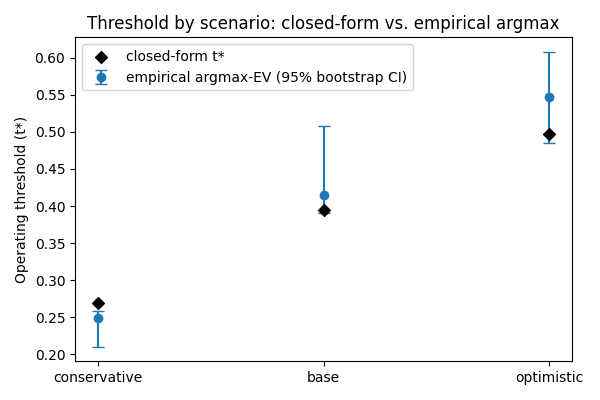


Shipped threshold (base scenario): 0.3941
Calibration method: sigmoid


In [8]:
threshold_rows = []
for name, scenario in threshold_payload["scenarios"].items():
    ci = scenario["argmax_ev_bootstrap_ci"]
    threshold_rows.append(
        {
            "scenario": name,
            "Threshold (formula)": scenario["threshold"],
            "Threshold (empirical)": scenario["argmax_ev_threshold"],
            "95% CI lower": ci[0],
            "95% CI upper": ci[1],
            "Within CI?": "Yes" if scenario["within_ci"] else "No",
            "Contact rate": scenario["implied_contact_rate"],
        }
    )
threshold_df = pd.DataFrame(threshold_rows).set_index("scenario")
display(
    threshold_df.style.format(
        {
            "Threshold (formula)": "{:.4f}",
            "Threshold (empirical)": "{:.4f}",
            "95% CI lower": "{:.4f}",
            "95% CI upper": "{:.4f}",
            "Contact rate": "{:.1%}",
        }
    )
)

scenario_plot_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/threshold_by_scenario.png"
)
display(Image(filename=scenario_plot_path))

assert threshold_payload["scenarios"]["base"]["within_ci"], (
    "The shipped base-scenario threshold no longer agrees with the empirical "
    "argmax-EV diagnostic — this notebook's narrative below assumes agreement "
    "and needs revisiting if this assertion ever fails."
)
print(f"\nShipped threshold (base scenario): {threshold_payload['threshold']:.4f}")
print(f"Calibration method: {threshold_payload['calibration_method']}")

The diamond sits inside the bar for base and optimistic (within about 0.02–0.05, just estimation noise) but outside it for **conservative** — its threshold (0.2696) falls just above the empirical range ([0.2106, 0.2586]), a real disagreement, though it doesn't affect the shipped policy (base still agrees). **Why:** the formula has zero sampling variance — it's just arithmetic — while the empirical peak is a statistic estimated from finite data and carries uncertainty the formula doesn't; conservative's miss (about 0.011, a fifth of the range's width) is real but modest.

**Not a calibration problem:** the calibration slope (≈1.01) is an aggregate over the whole probability range and can look fine while one narrow slice (~0.25–0.27) is locally off — that's exactly what this check catches. It's a **diagnostic, not a gate**: nothing here blocks the shipped policy. Raising the assumed retention rate (conservative → optimistic) raises the threshold and shrinks the **contact rate** from about 40% to about 24%.


### Expected-value curves, by scenario

Expected value applies the same cost logic as the threshold, spread across every possible cutoff: **EV(t) = [caught churners × (retention value − cost) − wasted contacts × cost] ÷ total customers**. Every churner caught pays back the retention value minus the cost of the call; every contact wasted on someone who wasn't going to churn is a pure loss of that cost. Averaged across the whole customer base, this gives one dollar figure per cutoff `t` — the number plotted below.


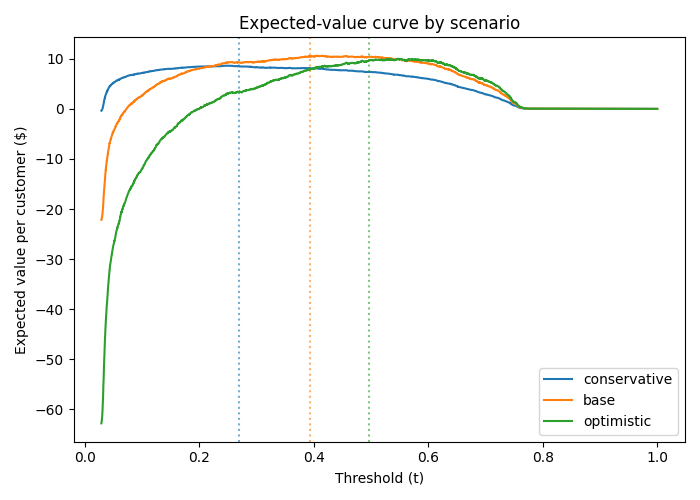

,t*,EV at t* ($/customer)
scenario,,
conservative,0.2696,8.51
base,0.3941,10.45
optimistic,0.4968,9.62


In [9]:
ev_curve_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/expected_value_by_scenario.png"
)
display(Image(filename=ev_curve_path))

ev_at_tstar_rows = []
for name, scenario in threshold_payload["scenarios"].items():
    ev_at_tstar_rows.append(
        {
            "scenario": name,
            "t*": scenario["threshold"],
            "EV at t* ($/customer)": scenario["dev_ev_at_t_star"],
        }
    )
ev_at_tstar_df = pd.DataFrame(ev_at_tstar_rows).set_index("scenario")
display(
    ev_at_tstar_df.style.format(
        {"t*": "{:.4f}", "EV at t* ($/customer)": "{:.2f}"}
    )
)

The table above states the dollar value at each shipped `t*` directly: **$10.45** per customer at the base threshold, **$8.51** at conservative's (more contacts, lower stake each), **$9.62** at optimistic's. **Why base beats optimistic despite optimistic's larger per-catch payoff:** optimistic's net benefit per catch ($136.52) is the biggest of the three, but its margin ratio (2.01×) is the thinnest, and its cost per false alarm ($134.78) is the highest. Base's healthier margin (2.54×) and higher contact rate (30.9% vs. 24.1%) win out in aggregate — a bigger per-success number doesn't guarantee a bigger campaign-wide average, and this follows from how the cost model scales the retention offer with ARPU (`configs/costs.yaml`), not from anything about the model or data.

The chart traces that dollar value across every cutoff. Contacting almost everyone (`t` near 0) costs money outright — sharply for base and optimistic, whose higher cost per contact makes over-contacting expensive; conservative stays closer to break-even. All three climb to a broad plateau of near-best cutoffs before falling back to $0 as the threshold approaches 1 (contacting no one). **For a business stakeholder, the takeaway is that neither extreme pays** — contacting everyone wastes money on people who were never at risk, and contacting no one gives up on customers who could have been saved — and the broad plateau in between means a slightly-off threshold costs little, which is why each `t*` (dotted line) sits somewhere on the plateau rather than exactly at its peak.


### Retention-rate sensitivity

The retention rate `r` is the fraction of contacted churners the offer actually saves — the one parameter this dataset cannot supply on its own, taken instead from an industry-benchmark range rather than fit. The sweep below holds the base scenario's cost and LTV fixed and varies only `r`, showing how much the shipped threshold would move under a different assumption.

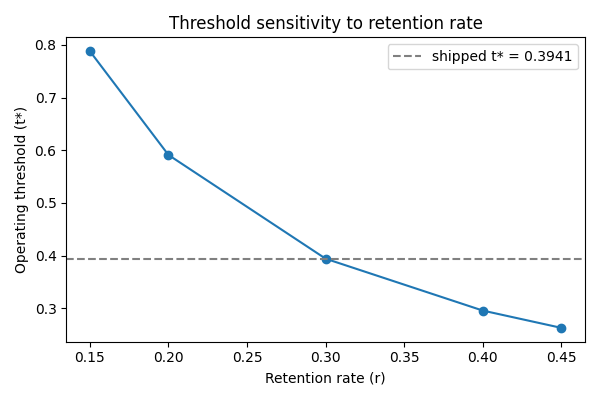

In [10]:
sensitivity_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/threshold_sensitivity.png"
)
display(Image(filename=sensitivity_path))

The operational threshold `t*` is inversely proportional to the retention rate `r` — halving the assumed retention rate exactly doubles the threshold, since `t*` and `r` are related by pure inverse proportionality once cost and lifetime value are fixed. Across the range tested here, the shipped threshold of 0.39 would need to rise to about 0.79 if the offer only saves half as many customers as assumed (`r = 0.15`), or could fall to about 0.26 if it saves nearly half again as many (`r = 0.45`).

For a business stakeholder, this means the offer's real-world effectiveness has direct financial consequences: if `r` turns out lower than assumed, the shipped threshold is too low and the team ends up contacting more customers than the offer's actual success rate justifies; if `r` is higher, it's too conservative and leaves customers uncontacted who could have been saved.

## Summary

This notebook loads the sigmoid-vs-isotonic calibration method selection and the closed-form cost-sensitive threshold derivation — both already computed by `calibrate.py` and `threshold.py` — and renders their reliability diagram, calibration slope, cost breakdown, agreement diagnostics, EV curves (with the expected value at each shipped threshold), and retention-rate sensitivity. Logic lives in those two modules; this notebook only loads and renders.

Sigmoid was selected over isotonic — better ranking, despite isotonic's edge on Brier and ECE — recovering a Brier Skill Score of 0.31. Its calibration slope (1.01) and mean predicted probability (within a point of the observed churn rate) together confirm the calibrated model is honest in both spread and level, on this dev-OOF read against **[§0](../ANALYSIS.md#0-problem-framing--cost-definition)**'s [0.80, 1.25] reference band — the binding check against that same band runs on the sealed test set in `evaluate.py`. The shipped threshold (`t* = 0.3941`, 30.9% contact rate, $10.45 expected value per customer) agrees with its empirical check, but is conditional on the assumed retention rate: the sensitivity sweep shows it ranging from 0.26 to 0.79 across plausible values of `r`. Conservative's empirical check disagrees narrowly with its closed-form threshold, though this doesn't affect the shipped base policy. Full narrative: **[§5 Probability Calibration](../ANALYSIS.md#5-probability-calibration)** and **[§6 Business Impact & Threshold Selection](../ANALYSIS.md#6-business-impact--threshold-selection)** in `ANALYSIS.md`.